In [1]:
from keras import models
from keras import layers
from numpy import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from keras.utils.np_utils import to_categorical
from tensorflow.python.ops.numpy_ops import np_config
np_config.enable_numpy_behavior()


In [2]:
n=10000
matiarial = tf.random.uniform(shape=[n,2], minval = -3,maxval=3, dtype=tf.float32, seed=10)
#print(matiarial)
i=0
label = np.empty(n,dtype=int)
#print(label)
for i in range(n):
    x = matiarial[i][0]
    y = matiarial[i][1]
    if((0.5-x*x-y*y)*(1-x*x-y*y)*(2-x*x-y*y)*(4-x*x-y*y)*(9-x*x-y*y)>0):
        label[i] = 1
    else:
        label[i] = 0

print(label)
   

[1 0 0 ... 1 1 1]


In [3]:
import math

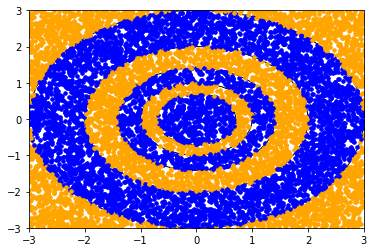

In [4]:
figure, axes = plt.subplots() 
axes.set(xlim=(-3, 3), ylim = (-3, 3))
cc1 = plt.Circle((0, 0), math.sqrt(0.5), color='black', fill=False)
cc2 = plt.Circle((0, 0), 1, color='black', fill=False) 
cc3 = plt.Circle((0, 0), math.sqrt(2), color='black', fill=False)
cc4 = plt.Circle((0, 0), 2, color='black', fill=False) 
cc5 = plt.Circle((0, 0), 3, color='black', fill=False)   
 

axes.add_artist( cc1 ) 
axes.add_artist( cc2 )
axes.add_artist( cc3 ) 
axes.add_artist( cc4 )
axes.add_artist( cc5 )

for i in range(n):
    if(label[i] == 1):
        point = plt.scatter(matiarial[i][0], matiarial[i][1], color='blue', s=10)
    if(label[i] == 0):
        point = plt.scatter(matiarial[i][0], matiarial[i][1], color='orange', s=10)
    axes.add_artist( point )

plt.show()

In [5]:
split_point = int(0.8*n)
train_set_data = matiarial[0:split_point,:] 
train_set_label = label[0:split_point]
test_set_data = matiarial[split_point:n,:] 
test_set_label = label[split_point:n]
for i in test_set_label:
    print(i)



0
1
0
1
0
1
0
1
1
0
1
0
0
0
1
1
1
0
1
0
1
1
1
0
1
1
0
0
0
0
1
1
0
0
1
0
1
1
1
1
0
0
1
1
1
0
1
0
0
1
0
1
1
0
0
1
0
1
0
1
0
1
1
1
1
1
1
1
1
0
0
0
1
1
1
0
0
0
0
0
0
1
0
1
1
0
1
0
1
0
0
1
1
0
1
1
1
0
1
1
0
1
1
0
0
1
1
1
0
1
1
0
1
1
1
1
1
0
0
0
0
1
0
0
1
0
1
0
1
0
1
1
1
0
0
1
0
0
1
0
1
1
1
1
0
0
0
1
0
0
1
0
1
1
1
1
1
1
0
1
0
1
0
1
1
1
1
1
1
0
1
1
1
1
1
1
1
1
1
0
0
1
1
0
1
1
0
1
1
0
0
1
1
1
1
1
0
0
1
1
0
0
0
0
0
1
1
1
0
1
0
1
1
1
1
1
0
0
0
1
0
0
1
1
1
1
0
1
0
0
1
1
0
1
0
0
1
1
0
1
1
0
1
0
0
1
1
1
0
1
0
0
1
0
1
1
1
1
0
0
1
1
0
1
1
1
0
1
1
0
0
1
0
1
1
0
1
1
1
0
1
0
1
0
0
0
0
0
0
0
0
1
0
0
1
1
1
0
0
0
1
1
1
1
0
1
1
1
1
0
1
0
1
1
0
0
1
0
1
0
0
0
0
0
1
1
0
0
1
0
1
0
1
1
1
1
1
0
1
1
1
1
1
1
0
1
1
0
0
0
1
1
1
1
1
1
1
1
1
0
1
0
0
0
1
0
1
0
1
1
1
0
0
1
1
1
1
0
1
1
1
1
1
1
1
0
1
1
0
0
1
0
0
1
1
0
0
0
1
1
1
1
0
0
0
0
1
0
0
1
1
1
0
0
1
0
0
1
1
0
0
1
0
1
1
0
0
0
1
1
1
1
1
0
1
0
1
0
0
0
0
1
1
0
1
1
1
1
0
1
1
1
0
1
0
0
1
0
0
1
1
1
1
1
0
0
1
0
0
1
1
1
1
1
1
1
0
1
1
1
1
1
1
0
0
1
1
0
1
1
0
1
1
1
1
1
1
0
1
1


In [21]:
network=models.Sequential()
feature_vector_shape = len(train_set_data[0])
input_shape = (feature_vector_shape,)
# When the following line is commented out, there are no layers
# in the network between input and output layers. The model reduces 
# to linear logistic regression.
# If you uncommnet the following line, one layer is added and
# we get a one-layer Neural Network

network.add(layers.Dense(80,activation='relu',input_shape=input_shape))
#network.add(layers.Dense(10,activation='relu'))
network.add(layers.Dense(70,activation='relu'))
network.add(layers.Dense(70,activation='relu'))
network.add(layers.Dense(70,activation='relu'))

network.add(layers.Dense(1,activation='sigmoid'))

network.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

train_set_datas = train_set_data.reshape(int(0.8*n),1*2)
#train_set_datas = train_set_data.astype('float32')/3

test_set_datas = test_set_data.reshape(int(0.2*n),1*2)
#test_set_datas = test_set_data.astype('float32')/3


#train_set_labels01 = to_categorical(train_set_label) # The target variable should be categorical
#test_set_labels01 = to_categorical(test_set_label)

network.fit(train_set_datas, train_set_label, epochs=20, batch_size=128) 

test_loss, test_acc=network.evaluate(test_set_datas, test_set_label) #Apply the learned network to the test data
print('test_acc:',test_acc)

predProb=network.predict(test_set_datas) # probabilities of digits
pred=list(map(np.argmax,predProb)) #predicted digit
pred = np.empty(n)




Epoch 1/20
63/63 [==============================] - 0s 1ms/step - loss: 0.6565 - accuracy: 0.6085
Epoch 2/20
63/63 [==============================] - 0s 1ms/step - loss: 0.6362 - accuracy: 0.6206
Epoch 3/20
63/63 [==============================] - 0s 992us/step - loss: 0.6323 - accuracy: 0.6221
Epoch 4/20
63/63 [==============================] - 0s 981us/step - loss: 0.6281 - accuracy: 0.6173
Epoch 5/20
63/63 [==============================] - 0s 877us/step - loss: 0.6241 - accuracy: 0.6255
Epoch 6/20
63/63 [==============================] - 0s 957us/step - loss: 0.6150 - accuracy: 0.6381
Epoch 7/20
63/63 [==============================] - 0s 972us/step - loss: 0.5990 - accuracy: 0.6479
Epoch 8/20
63/63 [==============================] - 0s 999us/step - loss: 0.5449 - accuracy: 0.6921
Epoch 9/20
63/63 [==============================] - 0s 1ms/step - loss: 0.4370 - accuracy: 0.7508
Epoch 10/20
63/63 [==============================] - 0s 1ms/step - loss: 0.3412 - accuracy: 0.8364
Epoch 1

In [24]:

pred = [1  if i >=0.5 else 0 for i in predProb]


<AxesSubplot:>

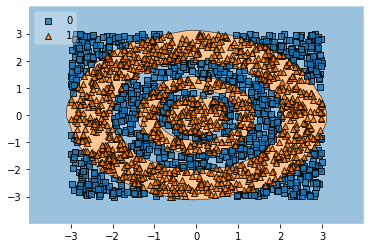

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(np.array(test_set_data), np.array(pred), clf=network, legend=2)

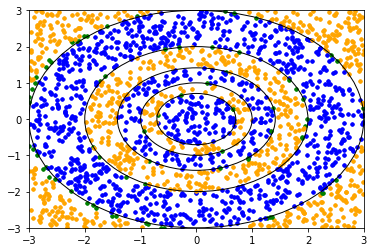

In [25]:
figure, axes2 = plt.subplots() 
axes2.set(xlim=(-3, 3), ylim = (-3, 3))
for i in range(len(test_set_datas)):
    if (test_set_label[i]==pred[i]):
        if(test_set_label[i] == 1):
            point = plt.scatter(test_set_datas[i][0], test_set_datas[i][1], color='blue', s=10)
        if(test_set_label[i] == 0):
            point = plt.scatter(test_set_datas[i][0], test_set_datas[i][1], color='orange', s=10)
    if (test_set_label[i]!=pred[i]):
        point = plt.scatter(test_set_datas[i][0], test_set_datas[i][1], color='green', s=10)
    axes2.add_artist( point )

cc1 = plt.Circle((0, 0), math.sqrt(0.5), color='black', fill=False)
cc2 = plt.Circle((0, 0), 1, color='black', fill=False) 
cc3 = plt.Circle((0, 0), math.sqrt(2), color='black', fill=False)
cc4 = plt.Circle((0, 0), 2, color='black', fill=False) 
cc5 = plt.Circle((0, 0), 3, color='black', fill=False) 

axes2.add_artist( cc1 ) 
axes2.add_artist( cc2 )
axes2.add_artist( cc3 ) 
axes2.add_artist( cc4 )
axes2.add_artist( cc5 )  
    
plt.show()
